# 移动游戏用户留存与 A/B Test 分析

## 1. 项目说明

本项目基于 Cookie Cats 公开移动游戏 A/B 测试数据集，围绕用户早期留存、版本效果差异和流失阶段定位进行分析。

原始数据包含用户实验分组、游戏局数、次日留存和 7 日留存结果。由于原始数据不包含逐日行为日志和首次活跃日期，本项目在保留原始数据的基础上，构造模拟逐日行为明细，用于补充 Cohort 留存、生命周期和流失阶段分析。

本 Notebook 的分析目标包括：

- 检查原始数据和扩写数据的基本情况
- 计算整体 D1、D3、D7 留存率
- 对比 gate_30 和 gate_40 两个实验组的留存差异
- 按用户活跃层级拆解留存和流失表现
- 构建 Cohort 留存分析表
- 输出可用于报告和看板的核心结果

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"

raw_path = DATA_DIR / "cookie_cats.csv"
profile_path = DATA_DIR / "game_user_profile_enriched.csv"
activity_path = DATA_DIR / "game_daily_activity_simulated.csv"

print("Project root:", PROJECT_ROOT)
print("Raw data exists:", raw_path.exists(), raw_path)
print("User profile exists:", profile_path.exists(), profile_path)
print("Daily activity exists:", activity_path.exists(), activity_path)

Project root: G:\data-analysis-portfolio\game-retention-analysis
Raw data exists: True G:\data-analysis-portfolio\game-retention-analysis\data\cookie_cats.csv
User profile exists: True G:\data-analysis-portfolio\game-retention-analysis\data\game_user_profile_enriched.csv
Daily activity exists: True G:\data-analysis-portfolio\game-retention-analysis\data\game_daily_activity_simulated.csv


In [4]:
raw_df = pd.read_csv(raw_path)
profile_df = pd.read_csv(profile_path)
activity_df = pd.read_csv(activity_path)

print("Raw data shape:", raw_df.shape)
print("User profile shape:", profile_df.shape)
print("Daily activity shape:", activity_df.shape)

Raw data shape: (90189, 5)
User profile shape: (90189, 14)
Daily activity shape: (721512, 9)


In [5]:
raw_df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [6]:
print("Raw data info:")
raw_df.info()

print("\nUser profile info:")
profile_df.info()

print("\nDaily activity info:")
activity_df.info()

Raw data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
userid            90189 non-null int64
version           90189 non-null object
sum_gamerounds    90189 non-null int64
retention_1       90189 non-null bool
retention_7       90189 non-null bool
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB

User profile info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 14 columns):
user_id              90189 non-null int64
experiment_group     90189 non-null object
sum_gamerounds       90189 non-null int64
retention_1          90189 non-null bool
retention_3          90189 non-null bool
retention_7          90189 non-null bool
install_date         90189 non-null object
first_active_date    90189 non-null object
cohort_date          90189 non-null object
cohort_week          90189 non-null object
is_new_user          90189 non-null bool
activity_segment     90189 non-n

In [7]:
missing_summary = pd.DataFrame({
    "raw_missing": raw_df.isna().sum(),
})

profile_missing = pd.DataFrame({
    "profile_missing": profile_df.isna().sum()
})

activity_missing = pd.DataFrame({
    "activity_missing": activity_df.isna().sum()
})

print("Raw missing values:")
display(missing_summary)

print("User profile missing values:")
display(profile_missing)

print("Daily activity missing values:")
display(activity_missing)

Raw missing values:


,raw_missing
userid,0
version,0
sum_gamerounds,0
retention_1,0
retention_7,0


User profile missing values:


,profile_missing
user_id,0
experiment_group,0
sum_gamerounds,0
retention_1,0
retention_3,0
retention_7,0
install_date,0
first_active_date,0
cohort_date,0
cohort_week,0


Daily activity missing values:


,activity_missing
user_id,0
experiment_group,0
install_date,0
active_date,0
day_n,0
is_active,0
daily_game_rounds,0
activity_segment,0
retention_flag,360756


In [8]:
print("Raw data duplicate userid:", raw_df["userid"].duplicated().sum())
print("User profile duplicate user_id:", profile_df["user_id"].duplicated().sum())

print("\nRaw version values:")
print(raw_df["version"].value_counts())

print("\nExperiment group values:")
print(profile_df["experiment_group"].value_counts())

print("\nRaw retention_1 values:")
print(raw_df["retention_1"].value_counts())

print("\nRaw retention_7 values:")
print(raw_df["retention_7"].value_counts())

Raw data duplicate userid: 0
User profile duplicate user_id: 0

Raw version values:
gate_40    45489
gate_30    44700
Name: version, dtype: int64

Experiment group values:
gate_40    45489
gate_30    44700
Name: experiment_group, dtype: int64

Raw retention_1 values:
False    50036
True     40153
Name: retention_1, dtype: int64

Raw retention_7 values:
False    73408
True     16781
Name: retention_7, dtype: int64


In [9]:
date_cols_profile = ["install_date", "first_active_date", "cohort_date", "cohort_week"]
date_cols_activity = ["install_date", "active_date"]

for col in date_cols_profile:
    profile_df[col] = pd.to_datetime(profile_df[col])

for col in date_cols_activity:
    activity_df[col] = pd.to_datetime(activity_df[col])

print(profile_df[date_cols_profile].dtypes)
print(activity_df[date_cols_activity].dtypes)

install_date         datetime64[ns]
first_active_date    datetime64[ns]
cohort_date          datetime64[ns]
cohort_week          datetime64[ns]
dtype: object
install_date    datetime64[ns]
active_date     datetime64[ns]
dtype: object


In [10]:
total_users = profile_df["user_id"].nunique()

retention_1_rate = profile_df["retention_1"].mean()
retention_3_rate = profile_df["retention_3"].mean()
retention_7_rate = profile_df["retention_7"].mean()
churn_7_rate = profile_df["is_churn_7d"].mean()

overall_metrics = pd.DataFrame({
    "metric": [
        "total_users",
        "D1_retention_rate",
        "D3_retention_rate",
        "D7_retention_rate",
        "D7_churn_rate"
    ],
    "value": [
        total_users,
        retention_1_rate,
        retention_3_rate,
        retention_7_rate,
        churn_7_rate
    ]
})

overall_metrics

,metric,value
0,total_users,90189.000000
1,D1_retention_rate,0.445210
2,D3_retention_rate,0.344133
3,D7_retention_rate,0.186065
4,D7_churn_rate,0.813935


In [11]:
overall_metrics_display = overall_metrics.copy()

overall_metrics_display["value"] = overall_metrics_display.apply(
    lambda row: f"{row['value']:.2%}" if "rate" in row["metric"] else f"{int(row['value']):,}",
    axis=1
)

overall_metrics_display

,metric,value
0,total_users,"90,189"
1,D1_retention_rate,44.52%
2,D3_retention_rate,34.41%
3,D7_retention_rate,18.61%
4,D7_churn_rate,81.39%


In [12]:
group_metrics = profile_df.groupby("experiment_group").agg(
    users=("user_id", "nunique"),
    avg_game_rounds=("sum_gamerounds", "mean"),
    median_game_rounds=("sum_gamerounds", "median"),
    d1_retention_rate=("retention_1", "mean"),
    d3_retention_rate=("retention_3", "mean"),
    d7_retention_rate=("retention_7", "mean"),
    d7_churn_rate=("is_churn_7d", "mean")
).reset_index()

group_metrics

,experiment_group,users,avg_game_rounds,median_game_rounds,d1_retention_rate,d3_retention_rate,d7_retention_rate,d7_churn_rate
0,gate_30,44700,52.456264,17,0.448188,0.347069,0.190201,0.809799
1,gate_40,45489,51.298776,16,0.442283,0.341247,0.182000,0.818000


In [13]:
group_metrics_display = group_metrics.copy()

percent_cols = [
    "d1_retention_rate",
    "d3_retention_rate",
    "d7_retention_rate",
    "d7_churn_rate"
]

for col in percent_cols:
    group_metrics_display[col] = group_metrics_display[col].map(lambda x: f"{x:.2%}")

group_metrics_display["avg_game_rounds"] = group_metrics_display["avg_game_rounds"].map(lambda x: f"{x:.2f}")
group_metrics_display["median_game_rounds"] = group_metrics_display["median_game_rounds"].map(lambda x: f"{x:.0f}")

group_metrics_display

,experiment_group,users,avg_game_rounds,median_game_rounds,d1_retention_rate,d3_retention_rate,d7_retention_rate,d7_churn_rate
0,gate_30,44700,52.46,17,44.82%,34.71%,19.02%,80.98%
1,gate_40,45489,51.30,16,44.23%,34.12%,18.20%,81.80%


In [14]:
gate_30 = group_metrics[group_metrics["experiment_group"] == "gate_30"].iloc[0]
gate_40 = group_metrics[group_metrics["experiment_group"] == "gate_40"].iloc[0]

diff_summary = pd.DataFrame({
    "metric": [
        "avg_game_rounds",
        "D1_retention_rate",
        "D3_retention_rate",
        "D7_retention_rate",
        "D7_churn_rate"
    ],
    "gate_30": [
        gate_30["avg_game_rounds"],
        gate_30["d1_retention_rate"],
        gate_30["d3_retention_rate"],
        gate_30["d7_retention_rate"],
        gate_30["d7_churn_rate"]
    ],
    "gate_40": [
        gate_40["avg_game_rounds"],
        gate_40["d1_retention_rate"],
        gate_40["d3_retention_rate"],
        gate_40["d7_retention_rate"],
        gate_40["d7_churn_rate"]
    ]
})

diff_summary["gate_40_minus_gate_30"] = diff_summary["gate_40"] - diff_summary["gate_30"]

diff_summary

,metric,gate_30,gate_40,gate_40_minus_gate_30
0,avg_game_rounds,52.456264,51.298776,-1.157488
1,D1_retention_rate,0.448188,0.442283,-0.005905
2,D3_retention_rate,0.347069,0.341247,-0.005822
3,D7_retention_rate,0.190201,0.182000,-0.008201
4,D7_churn_rate,0.809799,0.818000,0.008201


In [15]:
diff_summary_display = diff_summary.copy()

for idx, row in diff_summary_display.iterrows():
    metric = row["metric"]
    if "rate" in metric:
        diff_summary_display.loc[idx, "gate_30"] = f"{row['gate_30']:.2%}"
        diff_summary_display.loc[idx, "gate_40"] = f"{row['gate_40']:.2%}"
        diff_summary_display.loc[idx, "gate_40_minus_gate_30"] = f"{row['gate_40_minus_gate_30']:.2%}"
    else:
        diff_summary_display.loc[idx, "gate_30"] = f"{row['gate_30']:.2f}"
        diff_summary_display.loc[idx, "gate_40"] = f"{row['gate_40']:.2f}"
        diff_summary_display.loc[idx, "gate_40_minus_gate_30"] = f"{row['gate_40_minus_gate_30']:.2f}"

diff_summary_display

,metric,gate_30,gate_40,gate_40_minus_gate_30
0,avg_game_rounds,52.46,51.30,-1.16
1,D1_retention_rate,44.82%,44.23%,-0.59%
2,D3_retention_rate,34.71%,34.12%,-0.58%
3,D7_retention_rate,19.02%,18.20%,-0.82%
4,D7_churn_rate,80.98%,81.80%,0.82%


In [16]:
import math

def two_proportion_z_test(success_a, n_a, success_b, n_b):
    """
    两比例 Z 检验：
    用于比较两组用户的留存率是否存在显著差异。
    
    success_a: A 组留存用户数
    n_a: A 组总用户数
    success_b: B 组留存用户数
    n_b: B 组总用户数
    """
    p_a = success_a / n_a
    p_b = success_b / n_b
    
    pooled_p = (success_a + success_b) / (n_a + n_b)
    standard_error = math.sqrt(pooled_p * (1 - pooled_p) * (1 / n_a + 1 / n_b))
    
    z_score = (p_b - p_a) / standard_error
    
    # 正态分布双侧 p 值
    p_value = math.erfc(abs(z_score) / math.sqrt(2))
    
    return p_a, p_b, p_b - p_a, z_score, p_value

In [17]:
test_results = []

for metric_col, metric_name in [
    ("retention_1", "D1_retention"),
    ("retention_3", "D3_retention"),
    ("retention_7", "D7_retention")
]:
    group_data = profile_df.groupby("experiment_group")[metric_col].agg(["sum", "count"])
    
    success_30 = group_data.loc["gate_30", "sum"]
    n_30 = group_data.loc["gate_30", "count"]
    success_40 = group_data.loc["gate_40", "sum"]
    n_40 = group_data.loc["gate_40", "count"]
    
    p_30, p_40, diff, z_score, p_value = two_proportion_z_test(
        success_30, n_30, success_40, n_40
    )
    
    test_results.append({
        "metric": metric_name,
        "gate_30_rate": p_30,
        "gate_40_rate": p_40,
        "diff_gate40_minus_gate30": diff,
        "z_score": z_score,
        "p_value": p_value,
        "is_significant": p_value < 0.05
    })

ab_test_results = pd.DataFrame(test_results)
ab_test_results

,metric,gate_30_rate,gate_40_rate,diff_gate40_minus_gate30,z_score,p_value,is_significant
0,D1_retention,0.448188,0.442283,-0.005905,-1.784086,0.074410,False
1,D3_retention,0.347069,0.341247,-0.005822,-1.840063,0.065759,False
2,D7_retention,0.190201,0.182000,-0.008201,-3.164359,0.001554,True


In [18]:
ab_test_display = ab_test_results.copy()

for col in ["gate_30_rate", "gate_40_rate", "diff_gate40_minus_gate30"]:
    ab_test_display[col] = ab_test_display[col].map(lambda x: f"{x:.2%}")

ab_test_display["z_score"] = ab_test_display["z_score"].map(lambda x: f"{x:.3f}")
ab_test_display["p_value"] = ab_test_display["p_value"].map(lambda x: f"{x:.4f}")
ab_test_display["conclusion"] = ab_test_results["is_significant"].map(
    lambda x: "显著" if x else "不显著"
)

ab_test_display


,metric,gate_30_rate,gate_40_rate,diff_gate40_minus_gate30,z_score,p_value,is_significant,conclusion
0,D1_retention,44.82%,44.23%,-0.59%,-1.784,0.0744,False,不显著
1,D3_retention,34.71%,34.12%,-0.58%,-1.840,0.0658,False,不显著
2,D7_retention,19.02%,18.20%,-0.82%,-3.164,0.0016,True,显著


In [19]:
segment_metrics = profile_df.groupby("activity_segment").agg(
    users=("user_id", "nunique"),
    avg_game_rounds=("sum_gamerounds", "mean"),
    median_game_rounds=("sum_gamerounds", "median"),
    d1_retention_rate=("retention_1", "mean"),
    d3_retention_rate=("retention_3", "mean"),
    d7_retention_rate=("retention_7", "mean"),
    d7_churn_rate=("is_churn_7d", "mean")
).reset_index()

segment_metrics["user_share"] = segment_metrics["users"] / segment_metrics["users"].sum()

segment_metrics

,activity_segment,users,avg_game_rounds,median_game_rounds,d1_retention_rate,d3_retention_rate,d7_retention_rate,d7_churn_rate,user_share
0,heavy_player,22812,164.157154,109,0.856085,0.758329,0.549974,0.450026,0.252936
1,light_player,31995,4.491077,4,0.124863,0.069823,0.019347,0.980653,0.354755
2,medium_player,31388,25.165031,22,0.527017,0.362177,0.114279,0.885721,0.348025
3,not_started,3994,0.000000,0,0.021783,0.034051,0.007261,0.992739,0.044285


In [20]:
segment_metrics_display = segment_metrics.copy()

for col in ["user_share", "d1_retention_rate", "d3_retention_rate", "d7_retention_rate", "d7_churn_rate"]:
    segment_metrics_display[col] = segment_metrics_display[col].map(lambda x: f"{x:.2%}")

segment_metrics_display["avg_game_rounds"] = segment_metrics_display["avg_game_rounds"].map(lambda x: f"{x:.2f}")
segment_metrics_display["median_game_rounds"] = segment_metrics_display["median_game_rounds"].map(lambda x: f"{x:.0f}")

segment_metrics_display

,activity_segment,users,avg_game_rounds,median_game_rounds,d1_retention_rate,d3_retention_rate,d7_retention_rate,d7_churn_rate,user_share
0,heavy_player,22812,164.16,109,85.61%,75.83%,55.00%,45.00%,25.29%
1,light_player,31995,4.49,4,12.49%,6.98%,1.93%,98.07%,35.48%
2,medium_player,31388,25.17,22,52.70%,36.22%,11.43%,88.57%,34.80%
3,not_started,3994,0.00,0,2.18%,3.41%,0.73%,99.27%,4.43%


In [21]:
lifecycle_metrics = profile_df.groupby("lifecycle_stage").agg(
    users=("user_id", "nunique"),
    avg_game_rounds=("sum_gamerounds", "mean"),
    median_game_rounds=("sum_gamerounds", "median"),
    d1_retention_rate=("retention_1", "mean"),
    d3_retention_rate=("retention_3", "mean"),
    d7_retention_rate=("retention_7", "mean")
).reset_index()

lifecycle_metrics["user_share"] = lifecycle_metrics["users"] / lifecycle_metrics["users"].sum()

lifecycle_metrics

,lifecycle_stage,users,avg_game_rounds,median_game_rounds,d1_retention_rate,d3_retention_rate,d7_retention_rate,user_share
0,early_churn,14415,49.791467,26,1.000000,0.000000,0.073188,0.159831
1,mid_term_churn,13529,60.923719,41,1.000000,1.000000,0.000000,0.150007
2,newbie_churn,46129,18.814780,7,0.000000,0.113811,0.077500,0.511470
3,not_started,3994,0.000000,0,0.021783,0.034051,0.007261,0.044285
4,stable_active,12122,187.133889,130,1.000000,1.000000,1.000000,0.134407


In [22]:
lifecycle_metrics_display = lifecycle_metrics.copy()

for col in ["user_share", "d1_retention_rate", "d3_retention_rate", "d7_retention_rate"]:
    lifecycle_metrics_display[col] = lifecycle_metrics_display[col].map(lambda x: f"{x:.2%}")

lifecycle_metrics_display["avg_game_rounds"] = lifecycle_metrics_display["avg_game_rounds"].map(lambda x: f"{x:.2f}")
lifecycle_metrics_display["median_game_rounds"] = lifecycle_metrics_display["median_game_rounds"].map(lambda x: f"{x:.0f}")

lifecycle_metrics_display

,lifecycle_stage,users,avg_game_rounds,median_game_rounds,d1_retention_rate,d3_retention_rate,d7_retention_rate,user_share
0,early_churn,14415,49.79,26,100.00%,0.00%,7.32%,15.98%
1,mid_term_churn,13529,60.92,41,100.00%,100.00%,0.00%,15.00%
2,newbie_churn,46129,18.81,7,0.00%,11.38%,7.75%,51.15%
3,not_started,3994,0.00,0,2.18%,3.41%,0.73%,4.43%
4,stable_active,12122,187.13,130,100.00%,100.00%,100.00%,13.44%


In [23]:
cohort_daily = activity_df.groupby(["install_date", "day_n"]).agg(
    users=("user_id", "nunique"),
    active_users=("is_active", "sum")
).reset_index()

cohort_daily["retention_rate"] = cohort_daily["active_users"] / cohort_daily["users"]

cohort_daily.head(10)

,install_date,day_n,users,active_users,retention_rate
0,2026-04-01,0,2919,2919.0,1.000000
1,2026-04-01,1,2919,1313.0,0.449812
2,2026-04-01,2,2919,874.0,0.299418
3,2026-04-01,3,2919,979.0,0.335389
4,2026-04-01,4,2919,861.0,0.294964
5,2026-04-01,5,2919,835.0,0.286057
6,2026-04-01,6,2919,847.0,0.290168
7,2026-04-01,7,2919,542.0,0.185680
8,2026-04-02,0,2997,2997.0,1.000000
9,2026-04-02,1,2997,1333.0,0.444778


In [24]:
cohort_matrix = cohort_daily.pivot_table(
    index="install_date",
    columns="day_n",
    values="retention_rate"
)

cohort_matrix.head()

day_n,0,1,2,3,4,5,6,7
install_date,,,,,,,,
2026-04-01,1.0,0.449812,0.299418,0.335389,0.294964,0.286057,0.290168,0.185680
2026-04-02,1.0,0.444778,0.290958,0.345012,0.293961,0.303637,0.286286,0.185185
2026-04-03,1.0,0.445586,0.273194,0.352488,0.297271,0.299197,0.289888,0.183628
2026-04-04,1.0,0.449662,0.300096,0.348665,0.286587,0.295915,0.285944,0.193953
2026-04-05,1.0,0.442226,0.279542,0.328969,0.278232,0.286416,0.285106,0.178723


In [25]:
cohort_matrix_display = cohort_matrix.copy()

for col in cohort_matrix_display.columns:
    cohort_matrix_display[col] = cohort_matrix_display[col].map(lambda x: f"{x:.2%}")

cohort_matrix_display.head()

day_n,0,1,2,3,4,5,6,7
install_date,,,,,,,,
2026-04-01,100.00%,44.98%,29.94%,33.54%,29.50%,28.61%,29.02%,18.57%
2026-04-02,100.00%,44.48%,29.10%,34.50%,29.40%,30.36%,28.63%,18.52%
2026-04-03,100.00%,44.56%,27.32%,35.25%,29.73%,29.92%,28.99%,18.36%
2026-04-04,100.00%,44.97%,30.01%,34.87%,28.66%,29.59%,28.59%,19.40%
2026-04-05,100.00%,44.22%,27.95%,32.90%,27.82%,28.64%,28.51%,17.87%


In [26]:
group_retention_curve = activity_df.groupby(["experiment_group", "day_n"]).agg(
    users=("user_id", "nunique"),
    active_users=("is_active", "sum")
).reset_index()

group_retention_curve["retention_rate"] = (
    group_retention_curve["active_users"] / group_retention_curve["users"]
)

group_retention_curve

,experiment_group,day_n,users,active_users,retention_rate
0,gate_30,0,44700,44700.0,1.000000
1,gate_30,1,44700,20034.0,0.448188
2,gate_30,2,44700,13244.0,0.296286
3,gate_30,3,44700,15514.0,0.347069
4,gate_30,4,44700,13158.0,0.294362
5,gate_30,5,44700,13196.0,0.295213
6,gate_30,6,44700,13053.0,0.292013
7,gate_30,7,44700,8502.0,0.190201
8,gate_40,0,45489,45489.0,1.000000
9,gate_40,1,45489,20119.0,0.442283


In [27]:
group_retention_pivot = group_retention_curve.pivot_table(
    index="day_n",
    columns="experiment_group",
    values="retention_rate"
).reset_index()

group_retention_pivot["gate_40_minus_gate_30"] = (
    group_retention_pivot["gate_40"] - group_retention_pivot["gate_30"]
)

group_retention_pivot

experiment_group,day_n,gate_30,gate_40,gate_40_minus_gate_30
0,0,1.000000,1.000000,0.000000
1,1,0.448188,0.442283,-0.005905
2,2,0.296286,0.288993,-0.007293
3,3,0.347069,0.341247,-0.005822
4,4,0.294362,0.289586,-0.004776
5,5,0.295213,0.290532,-0.004681
6,6,0.292013,0.288619,-0.003394
7,7,0.190201,0.182000,-0.008201


In [28]:
group_retention_display = group_retention_pivot.copy()

for col in ["gate_30", "gate_40", "gate_40_minus_gate_30"]:
    group_retention_display[col] = group_retention_display[col].map(lambda x: f"{x:.2%}")

group_retention_display

experiment_group,day_n,gate_30,gate_40,gate_40_minus_gate_30
0,0,100.00%,100.00%,0.00%
1,1,44.82%,44.23%,-0.59%
2,2,29.63%,28.90%,-0.73%
3,3,34.71%,34.12%,-0.58%
4,4,29.44%,28.96%,-0.48%
5,5,29.52%,29.05%,-0.47%
6,6,29.20%,28.86%,-0.34%
7,7,19.02%,18.20%,-0.82%


In [29]:
import matplotlib.pyplot as plt

DASHBOARD_DIR = PROJECT_ROOT / "dashboard"
DASHBOARD_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

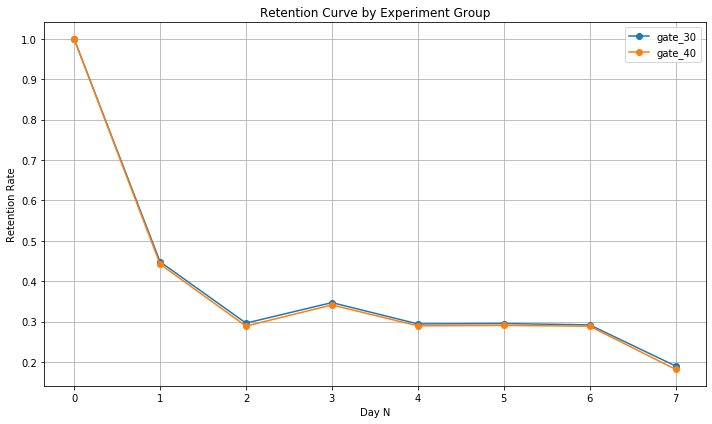

In [30]:
plt.figure(figsize=(10, 6))

for group in group_retention_curve["experiment_group"].unique():
    temp = group_retention_curve[group_retention_curve["experiment_group"] == group]
    plt.plot(
        temp["day_n"],
        temp["retention_rate"],
        marker="o",
        label=group
    )

plt.title("Retention Curve by Experiment Group")
plt.xlabel("Day N")
plt.ylabel("Retention Rate")
plt.xticks(range(0, 8))
plt.legend()
plt.tight_layout()

plt.savefig(DASHBOARD_DIR / "retention_curve_by_group.png", dpi=150)
plt.show()

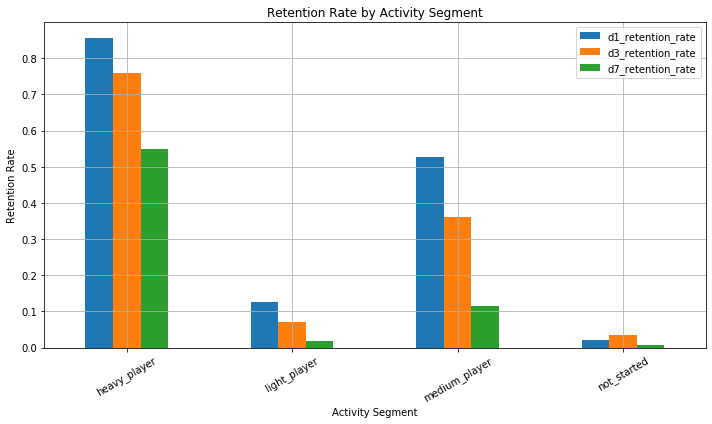

In [31]:
segment_plot = segment_metrics.set_index("activity_segment")[
    ["d1_retention_rate", "d3_retention_rate", "d7_retention_rate"]
]

segment_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Retention Rate by Activity Segment")
plt.xlabel("Activity Segment")
plt.ylabel("Retention Rate")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(DASHBOARD_DIR / "retention_by_activity_segment.png", dpi=150)
plt.show()

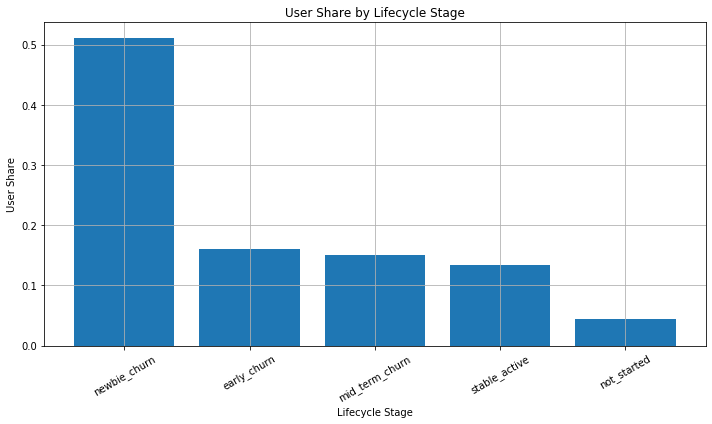

In [32]:
lifecycle_plot = lifecycle_metrics.sort_values("user_share", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(lifecycle_plot["lifecycle_stage"], lifecycle_plot["user_share"])

plt.title("User Share by Lifecycle Stage")
plt.xlabel("Lifecycle Stage")
plt.ylabel("User Share")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(DASHBOARD_DIR / "user_share_by_lifecycle_stage.png", dpi=150)
plt.show()

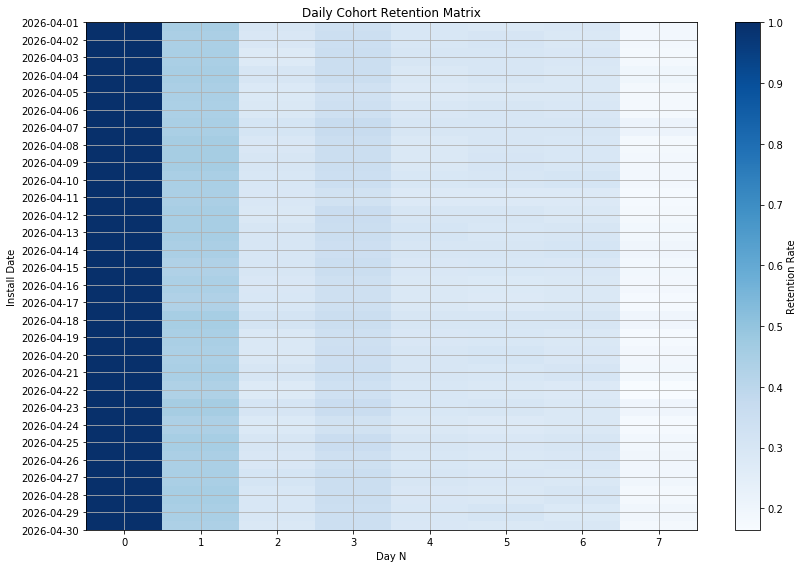

In [33]:
plt.figure(figsize=(12, 8))

plt.imshow(cohort_matrix, aspect="auto", cmap="Blues")

plt.title("Daily Cohort Retention Matrix")
plt.xlabel("Day N")
plt.ylabel("Install Date")

plt.xticks(
    ticks=range(len(cohort_matrix.columns)),
    labels=cohort_matrix.columns
)

plt.yticks(
    ticks=range(len(cohort_matrix.index)),
    labels=[d.strftime("%Y-%m-%d") for d in cohort_matrix.index]
)

plt.colorbar(label="Retention Rate")
plt.tight_layout()

plt.savefig(DASHBOARD_DIR / "cohort_retention_matrix.png", dpi=150)
plt.show()

In [34]:
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

In [35]:
overall_metrics.to_csv(REPORTS_DIR / "overall_metrics.csv", index=False, encoding="utf-8-sig")
group_metrics.to_csv(REPORTS_DIR / "group_metrics.csv", index=False, encoding="utf-8-sig")
diff_summary.to_csv(REPORTS_DIR / "group_diff_summary.csv", index=False, encoding="utf-8-sig")
ab_test_results.to_csv(REPORTS_DIR / "ab_test_results.csv", index=False, encoding="utf-8-sig")
segment_metrics.to_csv(REPORTS_DIR / "segment_metrics.csv", index=False, encoding="utf-8-sig")
lifecycle_metrics.to_csv(REPORTS_DIR / "lifecycle_metrics.csv", index=False, encoding="utf-8-sig")
cohort_matrix.to_csv(REPORTS_DIR / "cohort_retention_matrix.csv", encoding="utf-8-sig")
group_retention_pivot.to_csv(REPORTS_DIR / "group_retention_curve.csv", index=False, encoding="utf-8-sig")

print("Analysis tables exported to:", REPORTS_DIR)

Analysis tables exported to: G:\data-analysis-portfolio\game-retention-analysis\reports


In [36]:
summary_numbers = {
    "total_users": total_users,
    "overall_d1": retention_1_rate,
    "overall_d3": retention_3_rate,
    "overall_d7": retention_7_rate,
    "overall_churn_7": churn_7_rate,
    "gate30_d7": gate_30["d7_retention_rate"],
    "gate40_d7": gate_40["d7_retention_rate"],
    "gate40_minus_gate30_d7": gate_40["d7_retention_rate"] - gate_30["d7_retention_rate"],
}

summary_numbers

{'total_users': 90189,
 'overall_d1': 0.4452095044850259,
 'overall_d3': 0.34413287651487434,
 'overall_d7': 0.1860648194347426,
 'overall_churn_7': 0.8139351805652574,
 'gate30_d7': 0.19020134228187918,
 'gate40_d7': 0.18200004396667327,
 'gate40_minus_gate30_d7': -0.008201298315205913}

In [37]:
summary_numbers = {
    "total_users": total_users,
    "overall_d1": retention_1_rate,
    "overall_d3": retention_3_rate,
    "overall_d7": retention_7_rate,
    "overall_churn_7": churn_7_rate,
    "gate30_d7": gate_30["d7_retention_rate"],
    "gate40_d7": gate_40["d7_retention_rate"],
    "gate40_minus_gate30_d7": gate_40["d7_retention_rate"] - gate_30["d7_retention_rate"],
}

summary_numbers

{'total_users': 90189,
 'overall_d1': 0.4452095044850259,
 'overall_d3': 0.34413287651487434,
 'overall_d7': 0.1860648194347426,
 'overall_churn_7': 0.8139351805652574,
 'gate30_d7': 0.19020134228187918,
 'gate40_d7': 0.18200004396667327,
 'gate40_minus_gate30_d7': -0.008201298315205913}